In [1]:
import cv2
import numpy as np
import glob
import pandas as pd
import matplotlib.pyplot as plt
import torch
from calibration.networks import iResNet, LensNet 
import json

## Sample images

In [48]:
# Define the number of inside corners in the chessboard
chessboard_size = (24, 24)  # Example: 9x6 grid

# Prepare object points, like (0,0,0), (1,0,0), (2,0,0) ....,(6,5,0)
objp = np.zeros((np.prod(chessboard_size), 3), dtype=np.float32)
objp[:, :2] = np.mgrid[0:chessboard_size[0], 0:chessboard_size[1]].T.reshape(-1, 2)

# Arrays to store object points and image points from all the images.
# objpoints = np.array(pd.read_csv("/code/NeuroLens/data/target/Checkerboard points.csv"))  # 3d point in real world space
objpoints = []
imgpoints = []  # 2d points in image plane.

# Get the list of image files
images = glob.glob('data/target/images/10*0.png')  # Replace with your image path

for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Find the chessboard corners
    ret, corners = cv2.findChessboardCorners(gray, chessboard_size, None)
    corners = np.squeeze(corners) # remove extra dimension

    # If found, add object points, image points
    if ret == True:
        objpoints.append(objp)
        imgpoints.append(corners)

    break


### Save points

In [47]:
class NumpyArrayEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()  # Convert ndarray to list
        return json.JSONEncoder.default(self, obj)

cam_info = {
    "resolution_wh": img.shape[:2],
    "board_coordinates_xyz": objpoints,
    "frame_coordinates_xy": imgpoints
}
with open("data/target/points.json", "w") as f:
    json.dump(cam_info, f, cls=NumpyArrayEncoder)

### Vis

Chessboard corners detected successfully!


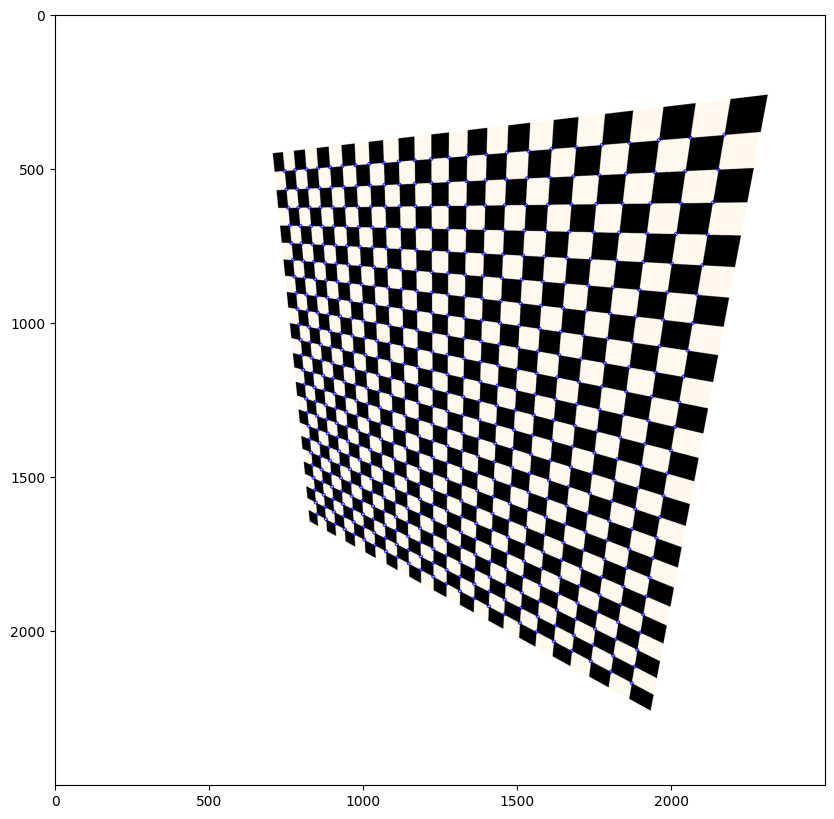

In [49]:
if ret:
    print("Chessboard corners detected successfully!")

    # Step 4: Draw circles at the detected corner locations
    for corner in corners:
        x, y = corner  # Extract x and y coordinates from the corner point
        cv2.circle(img, center=(int(x), int(y)), radius=5, color=(0, 0, 255), thickness=2)  # Red circle

    # Step 5: Display the image with detected corners
    plt.figure(figsize=(16, 10))
    plt.imshow(img)
else:
    print("Chessboard corners not detected.")

## Debug

In [57]:
def vis_points(img, points_tensor):
    points_numpy = points_tensor.detach().cpu().numpy()

    # Step 3: Plot the points on the image
    for point in points_numpy:
        x, y = point  # Extract x and y coordinates
        cv2.circle(img, center=(int(x), int(y)), radius=5, color=(255, 0, 0), thickness=-1)
    plt.figure(figsize=(16, 10))
    plt.imshow(img)

In [51]:
import torch

dev = torch.device("cuda")
lens_net = iResNet().to(dev)
checkpoint = torch.load("data/logs/lensnet_latest.pt")
lens_net.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [52]:
checkpoint.keys()

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'K', 'RTs_train', 'RTs_val', 'loss'])

In [58]:
from calibration.camera import Camera
cam = Camera(resolution_w_h=img.shape[:2], K=checkpoint["K"], lensnet=lens_net, RT=checkpoint["RTs_val"][0])

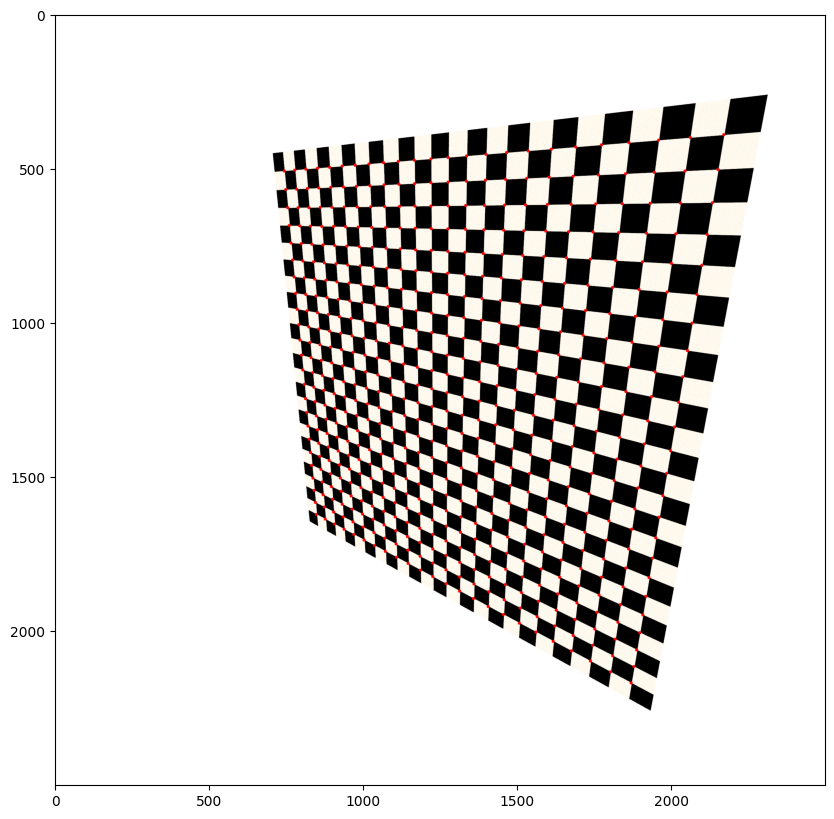

In [59]:
objp_tensor = torch.tensor(objp).to(dev)
projected = cam.project_points(objp_tensor)
img = cv2.imread(fname)
vis_points(img, projected)